<a href="https://colab.research.google.com/github/awinarko-hue/Latihan/blob/main/ER_NLP_ML/Entity_Resolution_SBERT_FAISS_XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Setup & Instalasi

Library utama:
- `sentence-transformers` → model embedding multilingual MiniLM
- `faiss-cpu` → vector database untuk pencarian semantik
- `xgboost`, `lightgbm` → classifier ensemble
- `python-Levenshtein` → jarak edit string

In [ ]:
!pip install -q sentence-transformers faiss-cpu xgboost lightgbm python-Levenshtein

import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

import faiss
import Levenshtein
from sentence_transformers import SentenceTransformer

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_score, recall_score, f1_score)
import xgboost as xgb
import lightgbm as lgb

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Setup selesai ✓")

Setup selesai ✓


## 2. Load & Eksplorasi Data

Upload dua file:
- **`listing_marketplace.csv`** — hasil scraping Tokopedia (kolom `data2` = judul listing "kotor")
- **`DJID.csv`** — database sertifikasi resmi SDPPI (ground truth: `merk`, `model`, `nama_pemasaran`, dll.)

In [ ]:
from google.colab import files
uploaded = files.upload()  # upload listing_marketplace.csv dan DJID.csv

Saving DJID.csv to DJID.csv
Saving listing_marketplace.csv to listing_marketplace.csv


In [ ]:
df_listing = pd.read_csv('listing_marketplace.csv', encoding='utf-8-sig')
df_djid    = pd.read_csv('DJID.csv', encoding='utf-8-sig')

print(f"Listing marketplace : {df_listing.shape[0]} baris, {df_listing.shape[1]} kolom")
print(f"Database DJID/SDPPI : {df_djid.shape[0]} baris, {df_djid.shape[1]} kolom")

display(df_listing.head(3))
display(df_djid.head(3))

Listing marketplace : 1019 baris, 6 kolom
Database DJID/SDPPI : 1333 baris, 11 kolom


,web_scraper_order,web_scraper_start_url,data,data2,data3,image
0,1782458402-1,https://www.tokopedia.com/pusatht-official-sto...,Rp2950000,Radio HT Handy Talky MagOne by Motorola X10d A...,Hemat s.d 5% Pakai Bonus,https://drive.google.com/file/d/1MxkRT46TVmruV...
1,1782458402-2,https://www.tokopedia.com/pusatht-official-sto...,Rp2900000,Radio HT ICOM IC-V88 VHF Walkie Talkie 5W Outp...,Hemat s.d 5% Pakai Bonus,https://drive.google.com/file/d/1IVdzawVByV0i1...
2,1782458402-3,https://www.tokopedia.com/pusatht-official-sto...,Rp65000000,Radio HF / SSB/ Base Station Marine Kapal ICOM...,Hemat s.d 5% Pakai Bonus,https://drive.google.com/file/d/1l3SR3TQu6mNZu...


,web_scraper_order,web_scraper_start_url,nomor_sertifikat,tanggal_terbit,plg_id,nama_pemohon,nama_perangkat,merk,model,nama_pemasaran,negara
0,1782485218-1,https://sertifikasi.postel.go.id/sertifikat/se...,122936/DJID/2026,15 Jun 2026,1889,PT CITRADATA PURNAKHARISMA,Radio Portable / Two Way Radio,MOTOROLA,XiR P6600i,MOTOROLA XiR P6600i UHF 403-470MHz,Malaysia
1,1782485218-2,https://sertifikasi.postel.go.id/sertifikat/se...,122867/DJID/2026,15 Jun 2026,16637,PT MERODITH TECHNOLOGY INDONESIA,TWO WAY RADIO,MERODITH,MD-T20,MERODITH,China
2,1782485218-3,https://sertifikasi.postel.go.id/sertifikat/se...,122716/DJID/2026,10 Jun 2026,1889,PT CITRADATA PURNAKHARISMA,Radio Portable / Two Way Radio,MOTOROLA,XiR C2660,MOTOROLA XiR C2660 UHF 403-470MHz,Malaysia


In [ ]:
# Eksplorasi singkat
print("=== Kolom listing ===")
print(df_listing.columns.tolist())
print("\n=== Kolom DJID ===")
print(df_djid.columns.tolist())

print("\n=== Distribusi merk di DJID (Top 15) ===")
print(df_djid['merk'].str.upper().str.strip().value_counts().head(15))

print("\n=== Contoh judul listing (kotor) ===")
for t in df_listing['data2'].head(5):
    print(" •", t)

=== Kolom listing ===
['web_scraper_order', 'web_scraper_start_url', 'data', 'data2', 'data3', 'image']

=== Kolom DJID ===
['web_scraper_order', 'web_scraper_start_url', 'nomor_sertifikat', 'tanggal_terbit', 'plg_id', 'nama_pemohon', 'nama_perangkat', 'merk', 'model', 'nama_pemasaran', 'negara']

=== Distribusi merk di DJID (Top 15) ===
merk
MOTOROLA           550
HYTERA              70
TAIT                70
ICOM                68
WEIERWEI            25
BAOFENG             23
VERTEX STANDARD     19
COMBA               17
KIRISUN             15
KENWOOD             14
GLOBAL WAVE         14
REDELL              14
CERNTEL             12
CENRF               12
SMP                 12
Name: count, dtype: int64

=== Contoh judul listing (kotor) ===
 • Radio HT Handy Talky MagOne by Motorola X10d Analog Digital DMR VHF / UHF Mag One Garansi resmi
 • Radio HT ICOM IC-V88 VHF Walkie Talkie 5W Output Power IP67 Resmi Garansi 1 Tahun Antena
 • Radio HF / SSB/ Base Station Marine Kapal ICOM IC-GM

## 3. Pembersihan Teks (Text Cleaning)

Judul marketplace penuh **noise pemasaran**: `"Garansi Resmi"`, `"Original"`, `"Murah"`, dsb.
Strategi:
1. Lowercase + hapus karakter non-alfanumerik
2. Hapus *noise words* (kata pemasaran yang tidak membawa informasi identitas produk)
3. Normalisasi spasi

> **Catatan metodologis:** kita simpan **dua versi** teks — versi bersih penuh (untuk embedding, karena SBERT justru bisa memanfaatkan konteks) dan versi tanpa-noise (untuk fitur leksikal seperti Jaccard/Levenshtein agar tidak bias oleh kata pemasaran).

In [ ]:
NOISE_WORDS = {
    'radio','ht','handy','talky','talkie','walkie','garansi','resmi','original','ori',
    'murah','promo','terbaru','baru','free','bonus','paket','termurah','berkualitas',
    'tahun','hemat','pakai','by','dan','dengan','satu','indonesia'
}

def clean_text(text):
    """Pembersihan dasar: lowercase, hapus simbol, rapikan spasi."""
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s\-]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def remove_noise(text):
    """Hapus kata-kata pemasaran yang tidak informatif."""
    tokens = [w for w in clean_text(text).split() if w not in NOISE_WORDS]
    return ' '.join(tokens)

df_listing['judul_bersih'] = df_listing['data2'].apply(clean_text)
df_listing['judul_inti']   = df_listing['data2'].apply(remove_noise)

df_listing[['data2','judul_inti']].head(8)

,data2,judul_inti
0,Radio HT Handy Talky MagOne by Motorola X10d A...,magone motorola x10d analog digital dmr vhf uh...
1,Radio HT ICOM IC-V88 VHF Walkie Talkie 5W Outp...,icom ic-v88 vhf 5w output power ip67 1 antena
2,Radio HF / SSB/ Base Station Marine Kapal ICOM...,hf ssb base station marine kapal icom ic-gm800...
3,Radio HF / SSB/ Base Station Marine Kapal ICOM...,hf ssb base station marine kapal icom ic-m804 ...
4,Radio HT Handy Talkie Berlin BL-968 BL 968 VHF...,berlin bl-968 bl 968 vhf uhf dual band output ...
5,Radio HF / SSB / Base Station ICOM IC-718 HF A...,hf ssb base station icom ic-718 hf all band tr...
6,Repeater Kenwood NXR-1800 NXR 1800 UHF DMR 40 ...,repeater kenwood nxr-1800 nxr 1800 uhf dmr 40 ...
7,Repeater Kenwood NXR-1700 NXR 1700 VHF DMR 50 ...,repeater kenwood nxr-1700 nxr 1700 vhf dmr 50 ...


## 4. Strukturisasi Data SDPPI → Dokumen Teks

Sesuai slide *"Fondasi Arsitektur Data"*: setiap record DJID (merk, model, nama pemasaran, jenis perangkat) digabung menjadi **satu dokumen teks** yang siap divektorisasi.

Contoh: `Merk: ICOM | Model: IC-V88 | Portable Radio` → `"icom ic-v88 icom ic-v88 vhf radio portable two way radio"`

In [ ]:
def build_djid_document(row):
    """Gabungkan field DJID menjadi satu dokumen teks untuk embedding."""
    parts = [
        str(row.get('merk', '')),
        str(row.get('model', '')),
        str(row.get('nama_pemasaran', '')),
        str(row.get('nama_perangkat', '')),
    ]
    doc = ' '.join(p for p in parts if p and p.lower() != 'nan')
    return clean_text(doc)

df_djid['dokumen'] = df_djid.apply(build_djid_document, axis=1)

# Identitas kanonik untuk display
df_djid['identitas'] = (df_djid['merk'].astype(str).str.strip() + ' ' +
                        df_djid['model'].astype(str).str.strip())

print("Contoh dokumen DJID:")
for d in df_djid['dokumen'].head(5):
    print(" •", d)

Contoh dokumen DJID:
 • motorola xir p6600i motorola xir p6600i uhf 403-470mhz radio portable two way radio
 • merodith md-t20 merodith two way radio
 • motorola xir c2660 motorola xir c2660 uhf 403-470mhz radio portable two way radio
 • motorola xir c2660 motorola xir c2660 vhf 136-174mhz radio portable two way radio
 • motorola r5 motorola r5 uhf 400-470mhz radio portable two way radio


## 5. Vektorisasi (Embedding) dengan Sentence-BERT

Model: **`paraphrase-multilingual-MiniLM-L12-v2`** (sesuai blueprint)
- Multilingual → cocok untuk teks campuran Indonesia–Inggris
- Output: vektor 384 dimensi per teks
- Vektor dinormalisasi (L2) agar *inner product* di FAISS = **cosine similarity**

In [ ]:
model_embed = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# Embedding korpus DJID (target pencarian)
emb_djid = model_embed.encode(df_djid['dokumen'].tolist(),
                              show_progress_bar=True,
                              normalize_embeddings=True)

# Embedding query marketplace
emb_listing = model_embed.encode(df_listing['judul_bersih'].tolist(),
                                 show_progress_bar=True,
                                 normalize_embeddings=True)

print(f"Shape embedding DJID    : {emb_djid.shape}")
print(f"Shape embedding listing : {emb_listing.shape}")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/42 [00:00<?, ?it/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Shape embedding DJID    : (1333, 384)
Shape embedding listing : (1019, 384)


## 6. Indexing & Retrieval dengan FAISS

Karena vektor sudah dinormalisasi, kita pakai `IndexFlatIP` (inner product) → skornya identik dengan **cosine similarity** (0–1).

Setiap judul marketplace di-query ke index → ambil **Top-K kandidat** dari DJID. Inilah *Fase Retrieval (Level Aplikasi)*.

In [ ]:
TOP_K = 5

d = emb_djid.shape[1]                 # dimensi vektor (384)
index = faiss.IndexFlatIP(d)          # inner product = cosine (vektor ternormalisasi)
index.add(emb_djid.astype('float32'))
print(f"Index FAISS berisi {index.ntotal} dokumen DJID")

# Retrieval Top-K untuk semua listing sekaligus
scores, indices = index.search(emb_listing.astype('float32'), TOP_K)
print(f"Hasil retrieval: {scores.shape} (n_listing × Top-{TOP_K})")

Index FAISS berisi 1333 dokumen DJID
Hasil retrieval: (1019, 5) (n_listing × Top-5)


In [ ]:
# Demo retrieval — seperti slide "Mekanisme Retrieval"
def demo_retrieval(idx_listing):
    print(f"QUERY : {df_listing.iloc[idx_listing]['data2'][:90]}")
    print("-" * 70)
    for rank in range(TOP_K):
        j = indices[idx_listing][rank]
        s = scores[idx_listing][rank]
        print(f"  {rank+1}. {df_djid.iloc[j]['identitas']:<40s} Score: {s:.3f}")

demo_retrieval(0)
print()
demo_retrieval(1)

QUERY : Radio HT Handy Talky MagOne by Motorola X10d Analog Digital DMR VHF / UHF Mag One Garansi 
----------------------------------------------------------------------
  1. Voxter UV-X5 ( 136-174 Mhz & 400-430 Mhz ) Score: 0.760
  2. Simoco EMEA SDP760 T1                    Score: 0.747
  3. KENWOOD NX-220 (136-174 MHz)             Score: 0.745
  4. Motorola MagOne A8 VHF 150-174 MHz       Score: 0.738
  5. MOTOROLA SL1M                            Score: 0.728

QUERY : Radio HT ICOM IC-V88 VHF Walkie Talkie 5W Output Power IP67 Resmi Garansi 1 Tahun Antena
----------------------------------------------------------------------
  1. ICOM IC-F44GT (FREQ.400-430MHz)          Score: 0.746
  2. ICOM IC-F5023H FREQ. 136-174MHz          Score: 0.743
  3. ICOM IC-F5023H FREQ. 136-174MHz          Score: 0.743
  4. TAIT TB8200 (762 - 870 MHz)              Score: 0.737
  5. ICOM IC-V80 (Freq. 136-174 MHz)          Score: 0.735


## 7. Membangun Dataset Pelatihan Terawasi (Ground Truth)

Sesuai slide *"Injeksi Kecerdasan"*: setiap pasangan (listing, kandidat DJID) diberi label biner:
- **1 (Match)** → entitas fisik yang sama
- **0 (Not Match)** → produk berbeda

**Strategi labeling 2 tahap:**
1. **Weak labeling otomatis** (heuristik): jika brand sama **dan** model number DJID muncul di judul listing → label sementara 1; jika brand beda → 0.
2. **Verifikasi manual** — pasangan diekspor ke CSV, Anda periksa/koreksi kolom `label`, lalu upload kembali. *Ini krusial untuk validitas ilmiah tesis.*

In [ ]:
# --- Ekstraksi brand & model untuk heuristik ---
BRANDS = set(df_djid['merk'].str.strip().str.lower().dropna().unique())

def find_brand(text):
    t = clean_text(text)
    for b in sorted(BRANDS, key=len, reverse=True):  # brand terpanjang dulu
        if re.search(r'\b' + re.escape(b) + r'\b', t):
            return b
    return None

def normalize_model(m):
    """'IC-V88' → 'icv88' agar 'ICV88', 'IC V88', 'IC-V88' dianggap sama."""
    return re.sub(r'[^a-z0-9]', '', str(m).lower())

df_listing['brand_terdeteksi'] = df_listing['data2'].apply(find_brand)
print(f"Listing dengan brand terdeteksi: {df_listing['brand_terdeteksi'].notna().sum()}/{len(df_listing)}")

Listing dengan brand terdeteksi: 820/1019


In [ ]:
# --- Bangun pasangan kandidat + weak label ---
pairs = []
for i in range(len(df_listing)):
    listing_text  = df_listing.iloc[i]['judul_bersih']
    listing_core  = df_listing.iloc[i]['judul_inti']
    listing_brand = df_listing.iloc[i]['brand_terdeteksi']
    listing_norm  = normalize_model(listing_text)

    for rank in range(TOP_K):
        j = indices[i][rank]
        row_djid = df_djid.iloc[j]
        djid_brand = str(row_djid['merk']).strip().lower()
        djid_model_norm = normalize_model(row_djid['model'])

        # Heuristik weak label
        brand_same = (listing_brand is not None) and (listing_brand == djid_brand)
        model_in_title = (len(djid_model_norm) >= 3) and (djid_model_norm in listing_norm)

        if brand_same and model_in_title:
            weak = 1
        elif listing_brand is not None and not brand_same:
            weak = 0
        else:
            weak = 0  # default konservatif; kandidat untuk review manual

        pairs.append({
            'idx_listing'  : i,
            'idx_djid'     : j,
            'rank'         : rank + 1,
            'judul_listing': df_listing.iloc[i]['data2'],
            'identitas_djid': row_djid['identitas'],
            'cosine_faiss' : float(scores[i][rank]),
            'brand_listing': listing_brand,
            'brand_djid'   : djid_brand,
            'label'        : weak,
            'perlu_review' : int(not brand_same and listing_brand is None),
        })

df_pairs = pd.DataFrame(pairs)
print(f"Total pasangan kandidat : {len(df_pairs)}")
print(f"Distribusi weak label   :\n{df_pairs['label'].value_counts()}")
print(f"Pasangan perlu review manual: {df_pairs['perlu_review'].sum()}")

Total pasangan kandidat : 5095
Distribusi weak label   :
label
0    4991
1     104
Name: count, dtype: int64
Pasangan perlu review manual: 995


In [ ]:
# --- Ekspor untuk verifikasi manual ---
df_pairs.to_csv('pasangan_kandidat_untuk_anotasi.csv', index=False)
files.download('pasangan_kandidat_untuk_anotasi.csv')

# Setelah dikoreksi manual, upload kembali dan jalankan:
# df_pairs = pd.read_csv('pasangan_kandidat_teranotasi.csv')
print("Silakan verifikasi kolom 'label' secara manual, terutama baris dengan perlu_review=1")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Silakan verifikasi kolom 'label' secara manual, terutama baris dengan perlu_review=1


In [ ]:
from google.colab import files
uploaded = files.upload()  # pilih file pasangan_kandidat_teranotasi.csv yang sudah diedit

# Get the actual filename from the uploaded dictionary
uploaded_filename = list(uploaded.keys())[0]
df_pairs = pd.read_csv(uploaded_filename)

# Finalisasi: buang yang masih -1 (ragu/belum direview)
df_labeled = df_pairs[df_pairs['label'] != -1].copy()

print(f"Dataset final: {len(df_labeled)} pasangan")
print(f"  Match (1)     : {(df_labeled['label']==1).sum()}")
print(f"  Not Match (0) : {(df_labeled['label']==0).sum()}")
print(f"  Dibuang (-1)  : {(df_pairs['label']==-1).sum()}")

Saving pasangan_kandidat_untuk_anotasi (5).csv to pasangan_kandidat_untuk_anotasi (5).csv
Dataset final: 5095 pasangan
  Match (1)     : 104
  Not Match (0) : 4991
  Dibuang (-1)  : 0


## 8. Feature Engineering — 6 Fitur Matematis

Sesuai slide *"Mesin Ekstraksi Fitur Matematis"*, setiap pasangan teks diubah menjadi vektor fitur:

| # | Fitur | Intuisi |
|---|-------|---------|
| 1 | **Cosine Similarity** | Kedekatan makna semantik (dari SBERT) |
| 2 | **Levenshtein Ratio** | Kemiripan karakter (typo-tolerant) |
| 3 | **Jaccard Similarity** | Irisan himpunan kata |
| 4 | **Token Overlap** | Proporsi token DJID yang muncul di listing |
| 5 | **Length Difference** | Selisih panjang teks (ternormalisasi) |
| 6 | **Brand Match** | Biner: merk sama atau tidak |

Ditambah 1 fitur bonus: **Model-in-Title** (model number DJID muncul di judul) — sangat diskriminatif di domain telekomunikasi.

In [ ]:
def extract_features(text_listing, text_djid, brand_listing, brand_djid,
                     model_djid, cosine_sim):
    """Ekstraksi 7 fitur dari satu pasangan kandidat."""
    t1, t2 = clean_text(text_listing), clean_text(text_djid)
    tok1, tok2 = set(t1.split()), set(t2.split())

    # 1. Cosine similarity (sudah dari FAISS)
    f_cosine = cosine_sim

    # 2. Levenshtein ratio (0-1, makin tinggi makin mirip)
    f_lev = Levenshtein.ratio(t1, t2)

    # 3. Jaccard similarity
    f_jaccard = len(tok1 & tok2) / len(tok1 | tok2) if (tok1 | tok2) else 0.0

    # 4. Token overlap (dari sisi DJID)
    f_overlap = len(tok1 & tok2) / len(tok2) if tok2 else 0.0

    # 5. Length difference (ternormalisasi)
    f_lendiff = abs(len(t1) - len(t2)) / max(len(t1), len(t2), 1)

    # 6. Brand match (biner)
    f_brand = int(brand_listing is not None and
                  str(brand_listing).lower() == str(brand_djid).lower())

    # 7. Model-in-title (biner)
    m_norm = normalize_model(model_djid)
    f_model = int(len(m_norm) >= 3 and m_norm in normalize_model(text_listing))

    return [f_cosine, f_lev, f_jaccard, f_overlap, f_lendiff, f_brand, f_model]

FEATURE_NAMES = ['cosine_sim', 'levenshtein', 'jaccard', 'token_overlap',
                 'length_diff', 'brand_match', 'model_in_title']

# Ekstraksi fitur untuk semua pasangan
X_list = []
for _, p in df_pairs.iterrows():
    row_djid = df_djid.iloc[int(p['idx_djid'])]
    feats = extract_features(
        p['judul_listing'], row_djid['dokumen'],
        p['brand_listing'], row_djid['merk'], # Corrected from row_djid['brand_djid']
        row_djid['model'], p['cosine_faiss']
    )
    X_list.append(feats)

X = pd.DataFrame(X_list, columns=FEATURE_NAMES)
y = df_pairs['label'].values

print(f"Matriks fitur: {X.shape}")
display(X.describe().round(3))

Matriks fitur: (5095, 7)


,cosine_sim,levenshtein,jaccard,token_overlap,length_diff,brand_match,model_in_title
count,5095.000,5095.000,5095.000,5095.000,5095.000,5095.000,5095.000
mean,0.683,0.353,0.081,0.204,0.400,0.518,0.028
std,0.096,0.078,0.062,0.152,0.215,0.500,0.166
min,0.161,0.139,0.000,0.000,0.000,0.000,0.000
25%,0.623,0.297,0.042,0.111,0.223,0.000,0.000
50%,0.691,0.348,0.077,0.200,0.408,1.000,0.000
75%,0.752,0.403,0.111,0.286,0.574,1.000,0.000
max,0.955,0.697,0.500,1.000,0.866,1.000,1.000


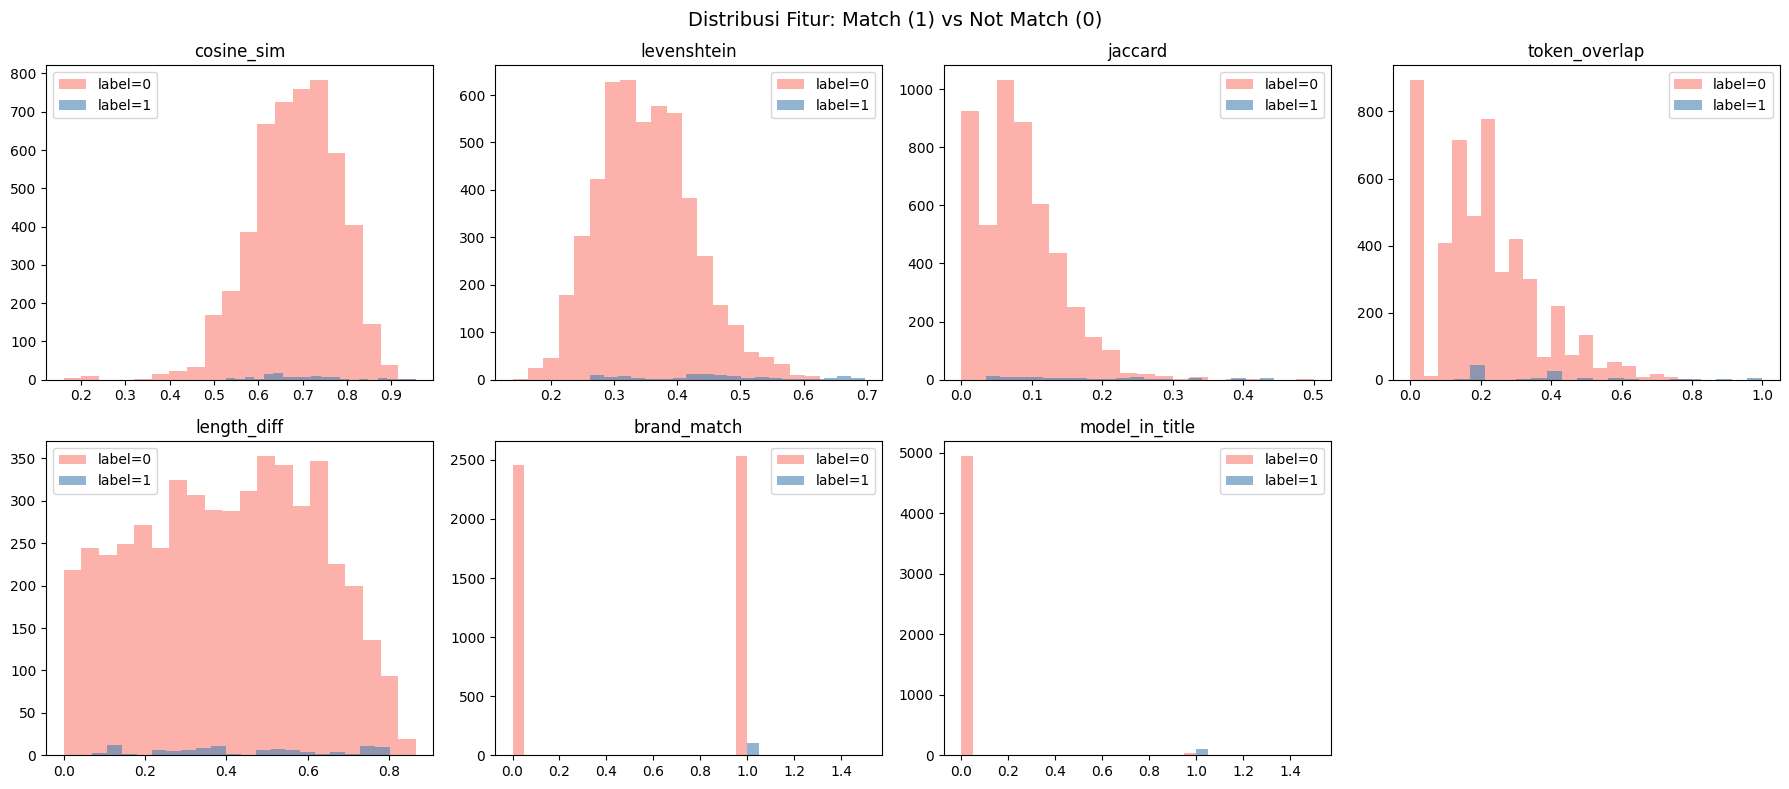

In [ ]:
# Visualisasi distribusi fitur per kelas
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, feat in zip(axes.ravel(), FEATURE_NAMES):
    for label_val, color in [(0, 'salmon'), (1, 'steelblue')]:
        ax.hist(X[y == label_val][feat], bins=20, alpha=0.6,
                color=color, label=f'label={label_val}')
    ax.set_title(feat); ax.legend()
axes.ravel()[-1].axis('off')
plt.suptitle('Distribusi Fitur: Match (1) vs Not Match (0)', fontsize=14)
plt.tight_layout(); plt.show()

## 9. Lapisan Klasifikasi Akhir: RF vs XGBoost vs LightGBM

Sesuai slide *"Lapisan Klasifikasi Akhir"*: tiga model ensemble dilatih pada fitur yang sama, lalu dibandingkan.

> **Catatan penting (imbalance):** pasangan Not-Match jauh lebih banyak dari Match — konsekuensi alami desain Top-K. Kita tangani dengan `class_weight='balanced'` / `scale_pos_weight`, dan **stratified split** agar proporsi kelas terjaga.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

print(f"Train: {X_train.shape}, positif={y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Test : {X_test.shape}, positif={y_test.sum()} ({y_test.mean()*100:.1f}%)")

ratio_neg_pos = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=3,
        class_weight='balanced', random_state=RANDOM_STATE),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.1,
        scale_pos_weight=ratio_neg_pos, eval_metric='logloss',
        random_state=RANDOM_STATE),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.1,
        class_weight='balanced', random_state=RANDOM_STATE, verbose=-1),
}

results = {}
for name, m in models.items():
    m.fit(X_train, y_train)
    y_pred = m.predict(X_test)
    results[name] = {
        'model'    : m,
        'y_pred'   : y_pred,
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall'   : recall_score(y_test, y_pred, zero_division=0),
        'f1'       : f1_score(y_test, y_pred, zero_division=0),
    }
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred, digits=3))

Train: (3821, 7), positif=78 (2.0%)
Test : (1274, 7), positif=26 (2.0%)

=== Random Forest ===
              precision    recall  f1-score   support

           0      1.000     1.000     1.000      1248
           1      1.000     1.000     1.000        26

    accuracy                          1.000      1274
   macro avg      1.000     1.000     1.000      1274
weighted avg      1.000     1.000     1.000      1274


=== XGBoost ===
              precision    recall  f1-score   support

           0      1.000     1.000     1.000      1248
           1      1.000     1.000     1.000        26

    accuracy                          1.000      1274
   macro avg      1.000     1.000     1.000      1274
weighted avg      1.000     1.000     1.000      1274


=== LightGBM ===
              precision    recall  f1-score   support

           0      1.000     1.000     1.000      1248
           1      1.000     1.000     1.000        26

    accuracy                          1.000      127

,Precision,Recall,F1-Score
Random Forest,1.0,1.0,1.0
XGBoost,1.0,1.0,1.0
LightGBM,1.0,1.0,1.0



Model terbaik (F1): Random Forest


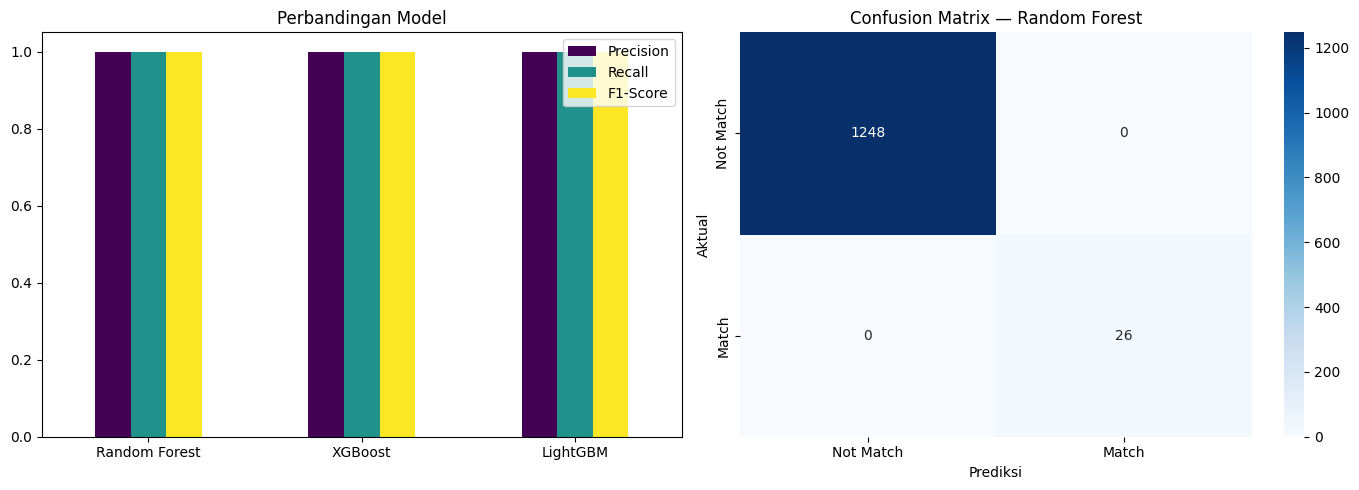

In [ ]:
# Perbandingan visual + confusion matrix model terbaik
df_res = pd.DataFrame({k: {'Precision': v['precision'],
                            'Recall': v['recall'],
                            'F1-Score': v['f1']} for k, v in results.items()}).T
display(df_res.round(3))

best_name = df_res['F1-Score'].idxmax()
print(f"\nModel terbaik (F1): {best_name}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_res.plot(kind='bar', ax=axes[0], rot=0, colormap='viridis')
axes[0].set_title('Perbandingan Model'); axes[0].set_ylim(0, 1.05)

cm = confusion_matrix(y_test, results[best_name]['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Not Match', 'Match'], yticklabels=['Not Match', 'Match'])
axes[1].set_title(f'Confusion Matrix — {best_name}')
axes[1].set_xlabel('Prediksi'); axes[1].set_ylabel('Aktual')
plt.tight_layout(); plt.show()

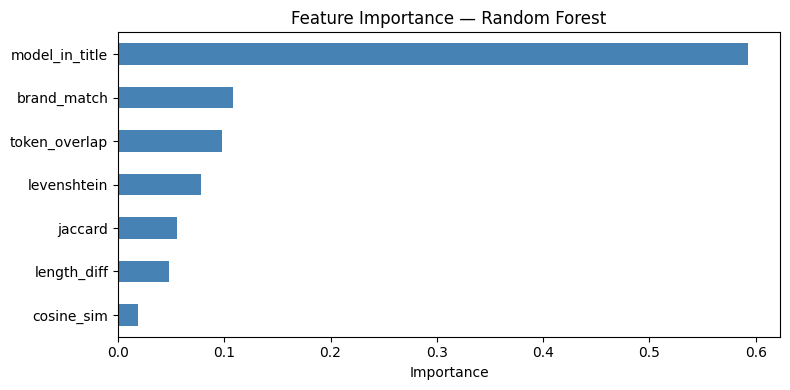

model_in_title    0.5933
brand_match       0.1078
token_overlap     0.0976
levenshtein       0.0785
jaccard           0.0560
length_diff       0.0481
cosine_sim        0.0187
dtype: float64


In [ ]:
# Feature importance model terbaik
best_model = results[best_name]['model']
imp = pd.Series(best_model.feature_importances_, index=FEATURE_NAMES).sort_values()

plt.figure(figsize=(8, 4))
imp.plot(kind='barh', color='steelblue')
plt.title(f'Feature Importance — {best_name}')
plt.xlabel('Importance'); plt.tight_layout(); plt.show()
print(imp.sort_values(ascending=False).round(4))

## 10. Evaluasi Retrieval: MAP@K dan MRR

Selain metrik klasifikasi, sistem retrieval dievaluasi secara keseluruhan (sesuai slide *"Parameter Keberhasilan"*):

- **MRR (Mean Reciprocal Rank)** — rata-rata `1/rank` dari match pertama yang benar. Mengukur *seberapa cepat* jawaban benar muncul di urutan atas.
- **MAP@K (Mean Average Precision)** — rata-rata precision pada setiap posisi match yang benar dalam Top-K.

Evaluasi hanya pada listing yang **memiliki minimal satu match** di ground truth.

In [ ]:
def evaluate_retrieval(df_pairs, k=TOP_K):
    rr_list, ap_list = [], []
    for idx, grup in df_pairs.groupby('idx_listing'):
        grup = grup.sort_values('rank')
        rels = grup['label'].values[:k]
        if rels.sum() == 0:
            continue  # listing tanpa match di ground truth → dilewati
        # Reciprocal Rank
        first_hit = np.argmax(rels == 1) + 1
        rr_list.append(1.0 / first_hit)
        # Average Precision @ K
        hits, precisions = 0, []
        for r, rel in enumerate(rels, start=1):
            if rel == 1:
                hits += 1
                precisions.append(hits / r)
        ap_list.append(np.mean(precisions))
    return np.mean(rr_list), np.mean(ap_list), len(rr_list)

mrr, map_k, n_eval = evaluate_retrieval(df_pairs)
print(f"Listing dievaluasi : {n_eval}")
print(f"MRR                : {mrr:.4f}")
print(f"MAP@{TOP_K}             : {map_k:.4f}")

Listing dievaluasi : 57
MRR                : 0.7535
MAP@5             : 0.7565


## 11. Fungsi Inferensi End-to-End

Pipeline lengkap untuk satu judul listing baru:
`judul kotor → embedding → FAISS Top-K → ekstraksi fitur → classifier → keputusan MATCH / NOT MATCH`

In [ ]:
def resolve_entity(judul_listing, top_k=TOP_K, threshold=0.5):
    """Entity resolution end-to-end untuk satu judul marketplace."""
    q_clean = clean_text(judul_listing)
    q_emb = model_embed.encode([q_clean], normalize_embeddings=True).astype('float32')
    s, idxs = index.search(q_emb, top_k)

    brand_q = find_brand(judul_listing)
    hasil = []
    for rank in range(top_k):
        j = idxs[0][rank]
        row = df_djid.iloc[j]
        feats = extract_features(judul_listing, row['dokumen'], brand_q,
                                 str(row['merk']).strip().lower(),
                                 row['model'], float(s[0][rank]))
        proba = best_model.predict_proba(pd.DataFrame([feats], columns=FEATURE_NAMES))[0, 1]
        hasil.append({
            'rank'        : rank + 1,
            'identitas'   : row['identitas'],
            'sertifikat'  : row['nomor_sertifikat'],
            'cosine'      : round(float(s[0][rank]), 3),
            'prob_match'  : round(float(proba), 3),
            'keputusan'   : 'MATCH ✓' if proba >= threshold else 'not match',
        })
    return pd.DataFrame(hasil)

# Uji coba
print("QUERY: Radio HT ICOM IC-V88 VHF Walkie Talkie 5W Garansi Resmi")
display(resolve_entity("Radio HT ICOM IC-V88 VHF Walkie Talkie 5W Garansi Resmi"))

print("\nQUERY: HT Baofeng UV-5R dual band murah original")
display(resolve_entity("HT Baofeng UV-5R dual band murah original"))

QUERY: Radio HT ICOM IC-V88 VHF Walkie Talkie 5W Garansi Resmi


,rank,identitas,sertifikat,cosine,prob_match,keputusan
0,1,HYTERA HM688,95796/SDPPI/2023,0.778,0.000,not match
1,2,Voxter UV-X5 ( 136-174 Mhz & 400-430 Mhz ),56592/SDPPI/2018,0.772,0.000,not match
2,3,Hytera HM688,94131/SDPPI/2023,0.772,0.005,not match
3,4,Hytera PD 788 G VHF,54920/SDPPI/2018,0.759,0.002,not match
4,5,Hytera PD788G VHF,37071/I/SDPPI/2017,0.753,0.005,not match



QUERY: HT Baofeng UV-5R dual band murah original


,rank,identitas,sertifikat,cosine,prob_match,keputusan
0,1,WEIERWEI UV-5R,92244/SDPPI/2023,0.698,0.185,not match
1,2,WEIERWEI UV-5R,60967/SDPPI/2019,0.689,0.169,not match
2,3,Baofeng UV - 5R,51697/R/SDPPI/2018,0.681,0.507,MATCH ✓
3,4,BAOFENG BF-H6,96721/SDPPI/2024,0.676,0.004,not match
4,5,Baofeng UV-5RE,32888/R/I/SDPPI/2018,0.675,0.036,not match


## 12. Simpan Artefak

Simpan model, index, dan dataset teranotasi untuk lampiran tesis / dashboard (Minggu 7 di roadmap).

In [ ]:
import joblib

joblib.dump(best_model, 'classifier_terbaik.pkl')
faiss.write_index(index, 'faiss_djid.index')
X.assign(label=y).to_csv('dataset_fitur_final.csv', index=False)
df_pairs.to_csv('pasangan_kandidat_final.csv', index=False)

print("Artefak tersimpan:")
print(" • classifier_terbaik.pkl")
print(" • faiss_djid.index")
print(" • dataset_fitur_final.csv")
print(" • pasangan_kandidat_final.csv")

# files.download('classifier_terbaik.pkl')  # uncomment untuk download

Artefak tersimpan:
 • classifier_terbaik.pkl
 • faiss_djid.index
 • dataset_fitur_final.csv
 • pasangan_kandidat_final.csv


---
## Catatan Metodologis

1. **Validitas ground truth** — weak label heuristik *harus* diverifikasi manual (Bagian 7) sebelum angka evaluasi dipakai di naskah. Laporkan berapa persen label yang dikoreksi (inter-annotator agreement jika ada 2 anotator).
2. **Data leakage** — fitur `brand_match` dan `model_in_title` juga dipakai dalam heuristik weak label. Setelah verifikasi manual, ini tidak masalah; tetapi jika memakai weak label mentah, classifier hanya "mempelajari kembali" heuristiknya sendiri.
3. **Imbalance** — rasio Not-Match : Match tinggi karena desain Top-K. `class_weight='balanced'` adalah baseline; eksperimen lanjutan bisa membandingkan dengan SMOTE.
4. **Split per-listing** — untuk klaim yang lebih kuat, pertimbangkan *group split* berdasarkan `idx_listing` agar pasangan dari listing yang sama tidak bocor antara train dan test (`GroupShuffleSplit`).
5. **Baseline pembanding** (Minggu 2 roadmap): TF-IDF + cosine, BM25, dan fuzzy matching murni — agar kontribusi SBERT+ML terukur.